<center>

# __Fairness in the Lab__

<br>

Dr. [Jose Maria Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

Ms. [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

__3 March 2026__
 
__Explainable and Trustworthy AI__

<br>

![MIA.png](MIA.png)

</center>

# **1. Introduction**

This interactive tutorial includes supplementary material for the second TAI in the Lab hands-on session (I5. "Fairness in the Lab") in the Subject **Explainable and Trustworthy AI** (Master in Artificial Intelligence). The session is leaded by [Jose M. Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral) and [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/) at USC, [Samuel Suárez Marcote](https://pdi.udc.es/es/File/Pdi/UA4VL![imagen.png](attachment:imagen.png)) at UDC, and [David Nicholas Olivieri Cecchi](https://www.uvigo.gal/es/universidad/administracion-personal/pdi/david-nicholas-olivieri-cecchi) at UVigo.

It is worth noting that the following materials are largely based on documentation and examples available at the [Fairlearn website](https://fairlearn.org/).

# **2. Settings**

This section is aimed for installing software and loading the required Python libraries.

In [1]:
## this code is developed by Jose Maria Alonso-Moral

import os

os.system("pip install -U scikit-image --quiet")

# Fairlearn
os.system("pip install fairlearn --quiet")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fairlearn 0.13.0 requires scipy<1.16.0,>=1.9.3, but you have scipy 1.17.1 which is incompatible.
scikit-learn 1.3.1 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.2 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.2 which is incompatible.
contourpy 1.1.1 requires numpy<2.0,>=1.16; python_version <= "3.11", but you have numpy 2.4.2 which is incompatible.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.4.2 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


0

In [2]:
## this code is developed by Jose Maria Alonso-Moral
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pprint import pprint

from sklearn import metrics as skm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from fairlearn.datasets import fetch_adult
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import DemographicParity, ErrorRate, GridSearch
from fairlearn.metrics import (
    MetricFrame, selection_rate, selection_rate_difference, equalized_odds_ratio, equalized_odds_difference, demographic_parity_difference, demographic_parity_ratio, false_negative_rate, false_positive_rate, true_negative_rate, true_positive_rate, count
)

# **3. Fairlearn**

In this section, we see first how to assess the fairness of a dataset by means of the [Fairlearn software](https://fairlearn.org/).

We will work with the well-known [Adult dataset](https://archive.ics.uci.edu/ml/datasets/Adult). The prediction task is to determine whether a person makes over $50K a year (binary classification), regarding the 1994 USA Census database. This dataset contains 14 attributes (including some sensitive attributes such as sex, race or education): 

* **age**
* **workclass** (Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked)
* **fnlwgt**
* **education** (Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool)
* **education-num**
* **marital-status** (Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse)
* **occupation** (Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces)
* **relationship** (Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried)
* **race** (White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black)
* **sex** (Female, Male)
* **capital-gain**
* **capital-loss**
* **hours-per-week**
* **native-country** (United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands)

In [3]:
# Load data
adult_data = fetch_openml(data_id=1590, as_frame=True)
X = pd.get_dummies(adult_data.data)
print(X)
y_true = (adult_data.target == '>50K') * 1
sex = adult_data.data['sex']
print(sex.value_counts())
race = adult_data.data['race']
print(race.value_counts())
education = adult_data.data['education']
print(education.value_counts())

        age    fnlwgt  education-num  capital-gain  capital-loss  \
0      25.0  226802.0            7.0           0.0           0.0   
1      38.0   89814.0            9.0           0.0           0.0   
2      28.0  336951.0           12.0           0.0           0.0   
3      44.0  160323.0           10.0        7688.0           0.0   
4      18.0  103497.0           10.0           0.0           0.0   
...     ...       ...            ...           ...           ...   
48837  27.0  257302.0           12.0           0.0           0.0   
48838  40.0  154374.0            9.0           0.0           0.0   
48839  58.0  151910.0            9.0           0.0           0.0   
48840  22.0  201490.0            9.0           0.0           0.0   
48841  52.0  287927.0            9.0       15024.0           0.0   

       hours-per-week  workclass_Federal-gov  workclass_Local-gov  \
0                40.0                  False                False   
1                50.0                  False 

In [4]:
X.head(n=10)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25.0,226802.0,7.0,0.0,0.0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,38.0,89814.0,9.0,0.0,0.0,50.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28.0,336951.0,12.0,0.0,0.0,40.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44.0,160323.0,10.0,7688.0,0.0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,18.0,103497.0,10.0,0.0,0.0,30.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34.0,198693.0,6.0,0.0,0.0,30.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
6,29.0,227026.0,9.0,0.0,0.0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,63.0,104626.0,15.0,3103.0,0.0,32.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
8,24.0,369667.0,10.0,0.0,0.0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
9,55.0,104996.0,4.0,0.0,0.0,10.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


Running the code below, you can visualize the fraction of males and females who earn over $50k.

        selection_rate  true_positive_rate
sex                                       
Female        0.109251                 1.0
Male          0.303767                 1.0
Difference:
selection_rate        0.194516
true_positive_rate    0.000000
dtype: float64
Ratio:
selection_rate        0.359655
true_positive_rate    1.000000
dtype: float64


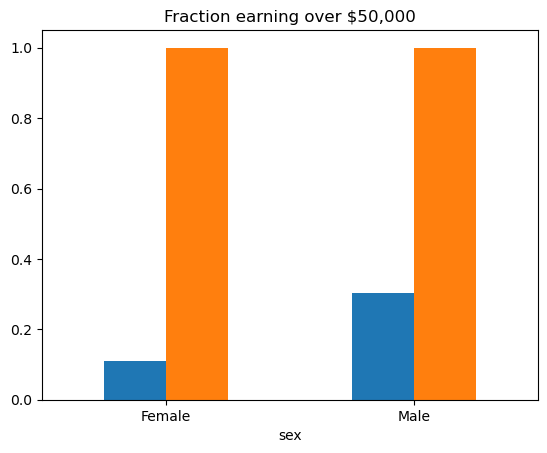

In [5]:
metrics_dict = {"selection_rate": selection_rate, "true_positive_rate": true_positive_rate}
selection_rates = MetricFrame(
    metrics=metrics_dict, y_true=y_true, y_pred=y_true, sensitive_features=sex
)
print(selection_rates.by_group)
print("Difference:")
print(selection_rates.difference())
print("Ratio:")
print(selection_rates.ratio())
fig = selection_rates.by_group.plot.bar(
    legend=False, rot=0, title="Fraction earning over $50,000"
)

With the code below we can remove correlations regarding a sensitive feature.

In [6]:
def plot_heatmap(df, title):
    cols = list(df.columns)
    print(cols)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(round(df.corr(), 2), cmap="coolwarm")

    # Loop over data dimensions and create text annotations.
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j,
                i,
                round(df.corr().to_numpy()[i, j], 2),
                ha="center",
                va="center",
            )

    ax.set_title(f"{title}")
    plt.show()

['age', 'sex_Female', 'sex_Male']


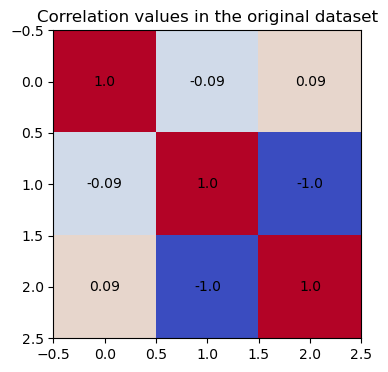

['age', 'sex_Female', 'sex_Male']


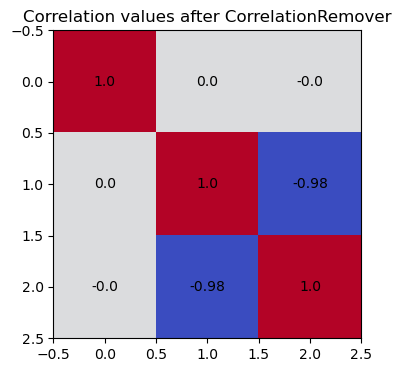

['age', 'sex_Female', 'sex_Male']


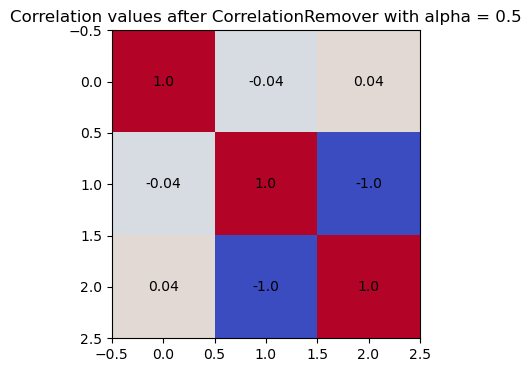

In [7]:
X_raw = adult_data.data[["age", "sex"]]
X_raw = pd.get_dummies(X_raw)
plot_heatmap(X_raw, "Correlation values in the original dataset")
cr = CorrelationRemover(sensitive_feature_ids=["sex_Male"])
X_cr = cr.fit_transform(X_raw)
X_cr = pd.DataFrame(X_cr, columns=['age', 'sex_Female'])
X_cr["sex_Male"] = X_raw["sex_Male"]
plot_heatmap(X_cr, "Correlation values after CorrelationRemover")
cr_alpha = CorrelationRemover(sensitive_feature_ids=['sex_Male'], alpha=0.5)
X_cr_alpha = cr_alpha.fit_transform(X_raw)
X_cr_alpha = pd.DataFrame(X_cr_alpha, columns=['age', 'sex_Female'])
X_cr_alpha["sex_Male"] = X_raw["sex_Male"]
plot_heatmap(X_cr_alpha, "Correlation values after CorrelationRemover with alpha = 0.5")

### **Exercise 1**
Modify the previous code with the aim of visualizing the fraction of people who earn over $50k regarding race. Then, plot correlations regarding age and race. Finally, remove correlations with alpha=0.7 for race_Black.

                    selection_rate  true_positive_rate
race                                                  
Amer-Indian-Eskimo        0.117021                 1.0
Asian-Pac-Islander        0.269256                 1.0
Black                     0.120811                 1.0
Other                     0.123153                 1.0
White                     0.253987                 1.0
Difference:
selection_rate        0.152235
true_positive_rate    0.000000
dtype: float64
Ratio:
selection_rate        0.43461
true_positive_rate    1.00000
dtype: float64


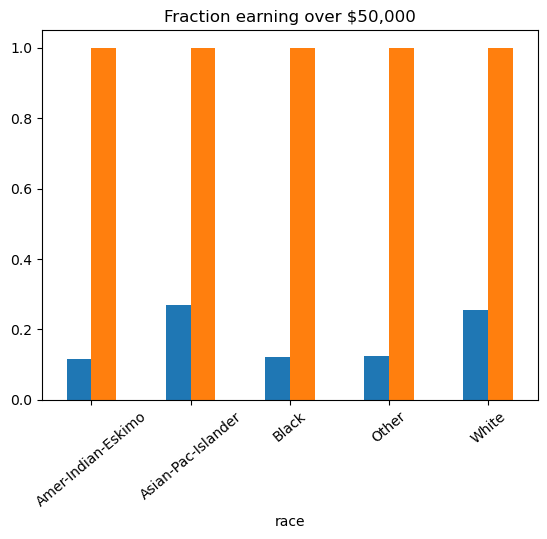

In [8]:
metrics_dict = {"selection_rate": selection_rate, "true_positive_rate": true_positive_rate}
selection_rates = MetricFrame(
    metrics=metrics_dict, y_true=y_true, y_pred=y_true, sensitive_features=race
)
print(selection_rates.by_group)
print("Difference:")
print(selection_rates.difference())
print("Ratio:")
print(selection_rates.ratio())
fig = selection_rates.by_group.plot.bar(
    legend=False, rot=40, title="Fraction earning over $50,000"
)

['age', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White']


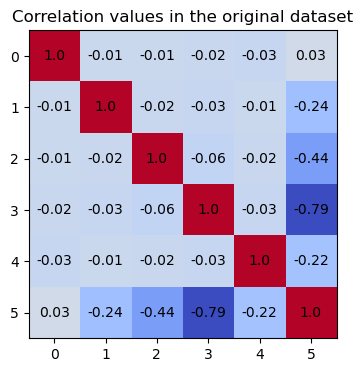

['age', 'race_White', 'race_Asian-Pac-Islander', 'race_Amer-Indian-Eskimo', 'race_Other', 'race_Black']


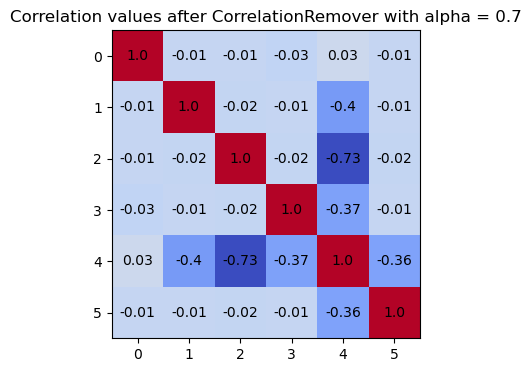

In [9]:
X_raw = adult_data.data[["age", "race"]]
X_raw = pd.get_dummies(X_raw)
plot_heatmap(X_raw, "Correlation values in the original dataset")
cr_alpha = CorrelationRemover(sensitive_feature_ids=['race_Black'], alpha=0.7)
X_cr_alpha = cr_alpha.fit_transform(X_raw)
X_cr_alpha = pd.DataFrame(X_cr_alpha, columns=['age', 'race_White', 'race_Asian-Pac-Islander', 'race_Amer-Indian-Eskimo', 'race_Other'])
X_cr_alpha["race_Black"] = X_raw["race_Black"]
plot_heatmap(X_cr_alpha, "Correlation values after CorrelationRemover with alpha = 0.7")

### **3.1 Building a fairness-unaware predictor**

Now, we are going to build a fairness-unaware predictor (LogisticRegression) and show how it leads to unfair decisions under a specific notion of fairness called [demographic parity](https://fairlearn.org/v0.8/api_reference/fairlearn.metrics.html#). We then mitigate unfairness by applying the GridSearch [fairlearn.reductions.GridSearch](https://fairlearn.org/v0.8/api_reference/fairlearn.reductions.html) algorithm.

In [10]:
A = sex
X = adult_data.data.drop(labels=["sex"], axis=1)
X = pd.get_dummies(X)

sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

le = LabelEncoder()
Y = le.fit_transform(y_true)
X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled, Y, A, test_size=0.25, random_state=0, stratify=Y
)

X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)

unmitigated_predictor = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor.fit(X_train, Y_train)

LogisticRegression(solver='liblinear')

Let us see how good the unmitigated predictor is from the ROC_AUC and Accuracy score viewpoint.

In [11]:
Y_pred_proba = unmitigated_predictor.predict_proba(X_test)[:, 1]
Y_pred = unmitigated_predictor.predict(X_test)
roc_auc_score(Y_test, Y_pred_proba)

0.9044674951693763

Let us assess the predictor’s fairness using the MetricFrame.
Please, look carefully at the disparity in accuracy: males have smaller accuracy than females. Nevertheless, the selection rate for males is greater than three times the rate for females (i.e., there is disparity in opportunity).

It is worth noting that despite the fact that we removed the feature sex from the training data, our predictor still discriminates based on sex. This demonstrates that simply ignoring a sensitive feature when fitting a predictor rarely eliminates unfairness. There will generally be enough other features correlated with the removed feature to lead to disparate impact.

accuracy                   0.854148
selection_rate             0.194988
true_positive_rate         0.602669
true_negative_rate         0.933254
false_positive_rate        0.602669
false_negative_rate        0.933254
count                  12211.000000
dtype: float64
        accuracy  selection_rate  true_positive_rate  true_negative_rate  \
sex                                                                        
Female  0.928150        0.077264            0.524554            0.978153   
Male    0.817233        0.253713            0.616815            0.904636   

        false_positive_rate  false_negative_rate   count  
sex                                                       
Female             0.524554             0.978153  4064.0  
Male               0.616815             0.904636  8147.0  


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'true_positive_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'true_negative_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'false_positive_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'false_negative_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

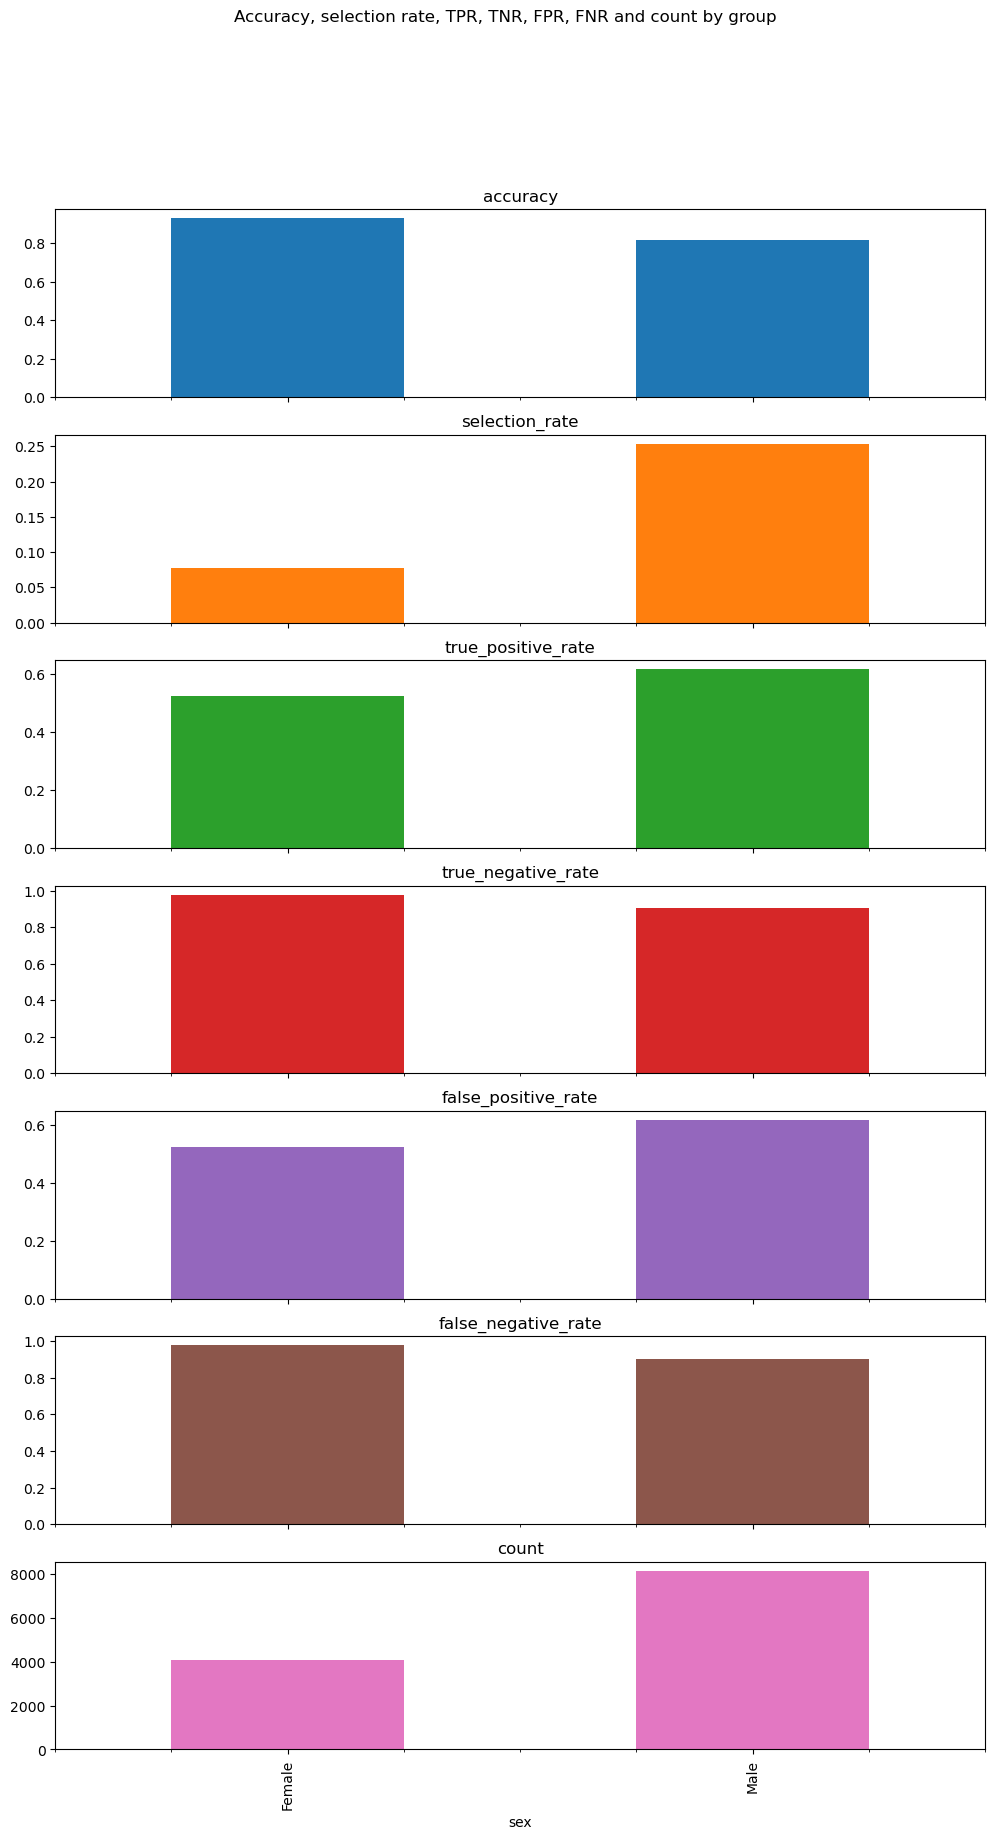

In [12]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "true_negative_rate": true_negative_rate,
        "false_positive_rate": true_positive_rate,
        "false_negative_rate": true_negative_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=unmitigated_predictor.predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[7, 1],
    legend=False,
    figsize=[12, 20],
    title="Accuracy, selection rate, TPR, TNR, FPR, FNR and count by group",
)

### **Exercise 2**
Repeat the previous analysis but considering now education as sensitive feature. Pay special attention to HS-grad versus Masters and comment the observed results.

ROC:  0.904868601067744
accuracy                   0.853738
selection_rate             0.196380
true_positive_rate         0.604723
true_negative_rate         0.932070
false_positive_rate        0.604723
false_negative_rate        0.932070
count                  12211.000000
dtype: float64
              accuracy  selection_rate  true_positive_rate  \
education                                                    
10th          0.953678        0.013624            0.166667   
11th          0.960280        0.014019            0.238095   
12th          0.894410        0.018634            0.111111   
1st-4th       1.000000        0.000000            0.000000   
5th-6th       0.943262        0.007092            0.111111   
7th-8th       0.913580        0.012346            0.050000   
9th           0.947368        0.000000            0.000000   
Assoc-acdm    0.846535        0.287129            0.759615   
Assoc-voc     0.825279        0.202602            0.554745   
Bachelors     0.808779     

array([[<Axes: title={'center': 'accuracy'}, xlabel='education'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'true_positive_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'true_negative_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'false_positive_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'false_negative_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'count'}, xlabel='education'>]],
      dtype=object)

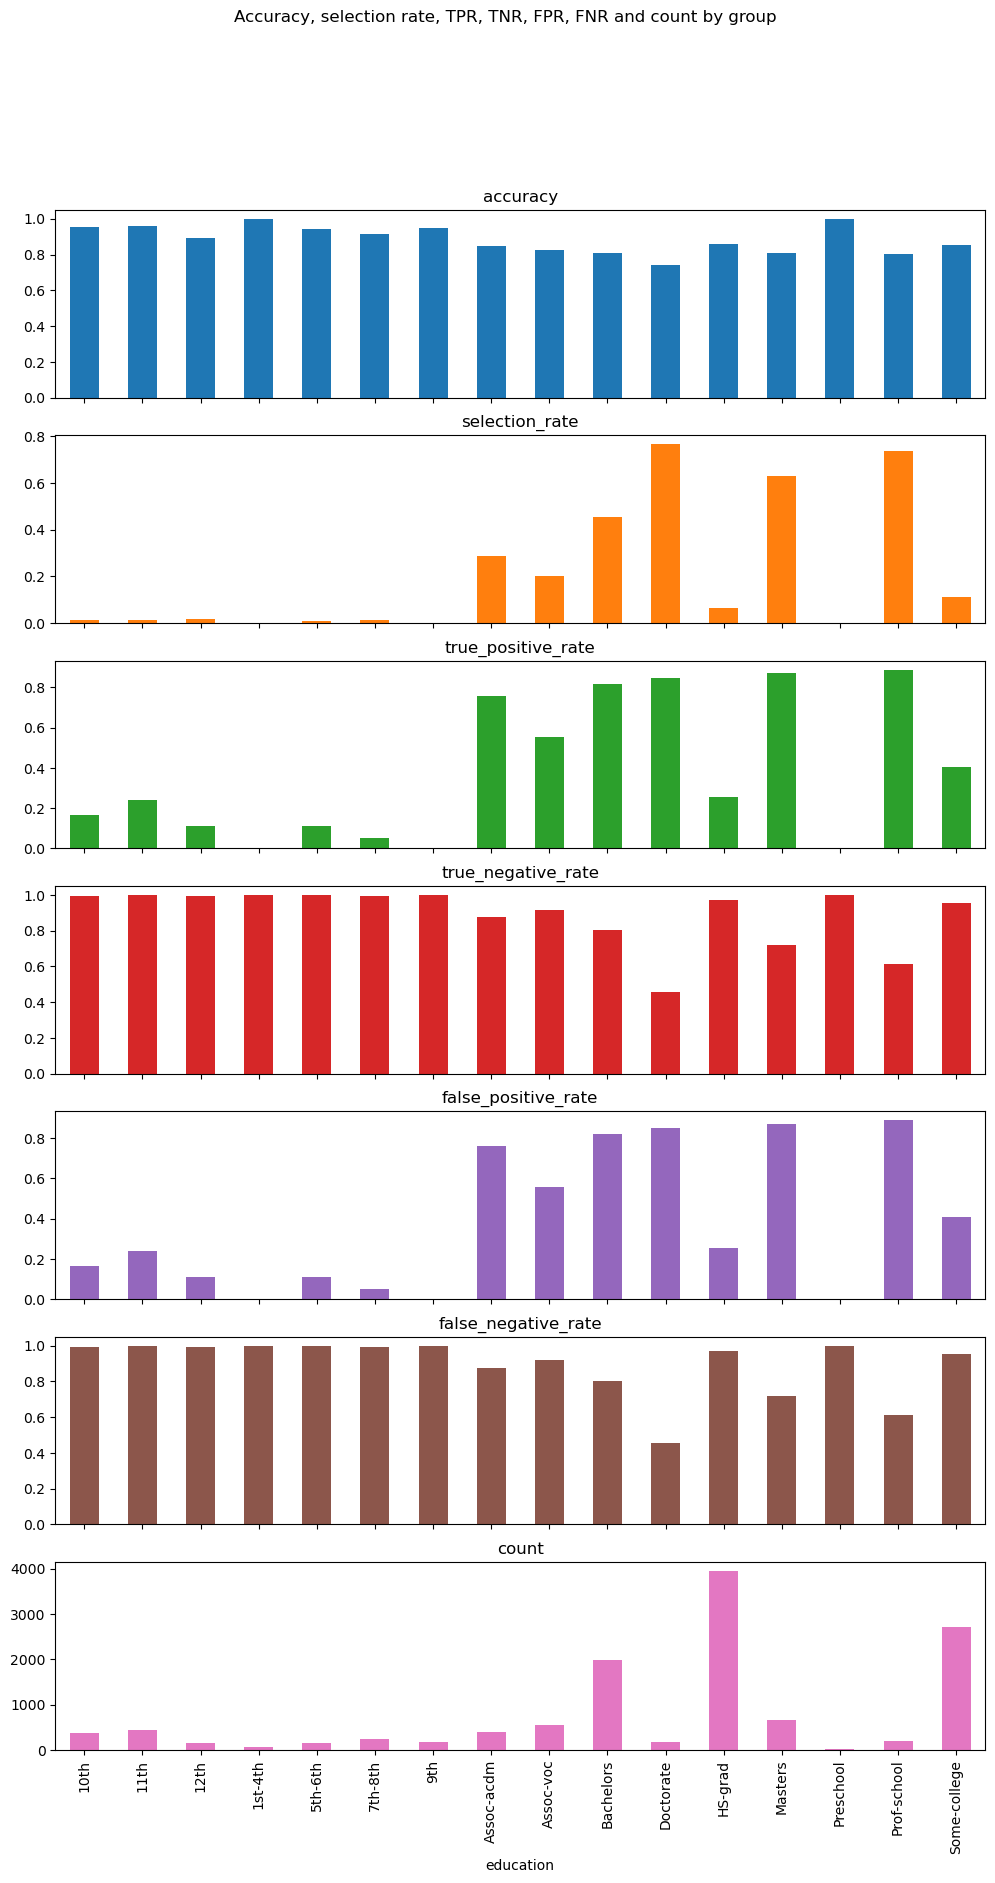

In [13]:
A = education
X = adult_data.data.drop(labels=["education"], axis=1)
X = pd.get_dummies(X)

sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

le = LabelEncoder()
Y = le.fit_transform(y_true)
X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled, Y, A, test_size=0.25, random_state=0, stratify=Y
)

X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)

unmitigated_predictor = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor.fit(X_train, Y_train)

Y_pred_proba = unmitigated_predictor.predict_proba(X_test)[:, 1]
Y_pred = unmitigated_predictor.predict(X_test)
print("ROC: ", roc_auc_score(Y_test, Y_pred_proba))

metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "true_negative_rate": true_negative_rate,
        "false_positive_rate": true_positive_rate,
        "false_negative_rate": true_negative_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=unmitigated_predictor.predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[7, 1],
    legend=False,
    figsize=[12, 20],
    title="Accuracy, selection rate, TPR, TNR, FPR, FNR and count by group",
)

### Answer Exercise 2

**Pay special attention to HS-grad versus Masters and comment the observed results.**

`The overall model performance is strong, with a ROC score of about 0.905 and an overall accuracy of 0.854. The overall selection rate is 0.196, meaning around 19.6% of individuals are predicted to earn over $50K. The overall true positive rate is 0.605 and the true negative rate is 0.932.`

`When focusing on education, there are clear differences between HS-grad and Masters. For HS-grad, the accuracy is 0.859, which is close to the overall accuracy, but the selection rate is very low (0.064), meaning only about 6.4% are predicted to earn over $50K. The true positive rate is also low (0.253), so only about 25% of actual high earners in this group are correctly identified. However, the true negative rate is very high (0.971), meaning the model is very good at predicting low income for this group. This shows that the model tends to predict low income for HS-grad individuals most of the time.`

`In contrast, for Masters, the accuracy is lower (0.809), but the selection rate is much higher (0.628), meaning about 62.8% are predicted to earn over $50K. The true positive rate is very high (0.871), so most actual high earners in this group are correctly classified. However, the true negative rate is lower (0.720), meaning more low earners are incorrectly predicted as high earners compared to HS-grad.`

`Overall, the model behaves very differently for these two education groups. It rarely predicts high income for HS-grad individuals, but very frequently predicts high income for those with a Master’s degree. These differences reflect strong disparities in prediction behavior across education levels, even though the overall model performance appears good.`

### **3.2 Mitigating bias: relabelling and reweighting**
We consider Demographic Parity (DP) on the sensitive feature sex as the fairness metric. DP requires that all individuals (no matter if they are males or females) are offered the same opportunity. We are going to remove the predictors which are dominated in the error-disparity space by others from the sweep which is defined below. Be patient because fitting the sweep may take long.

In [14]:
A = adult_data.data[['sex']] #sensitive feature
X = adult_data.data.drop(labels=['sex'], axis=1)
X = pd.get_dummies(X)
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
le = LabelEncoder()
Y = le.fit_transform(y_true)
X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled, Y, A, test_size=0.25, random_state=0, stratify=Y
)
X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)
unmitigated_predictor = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor.fit(X_train, Y_train)
sweep = GridSearch(
    LogisticRegression(solver="liblinear", fit_intercept=True),
    constraints=DemographicParity(),
    grid_size=31,
)

sweep.fit(X_train, Y_train, sensitive_features=A_train)
predictors = sweep.predictors_
errors, disparities = [], []
for m in predictors:

    def classifier(X):
        return m.predict(X)

    error = ErrorRate()
    error.load_data(X_train, pd.Series(Y_train), sensitive_features=A_train)
    disparity = DemographicParity()
    disparity.load_data(X_train, pd.Series(Y_train), sensitive_features=A_train)

    errors.append(error.gamma(classifier)[0])
    disparities.append(disparity.gamma(classifier).max())

all_results = pd.DataFrame(
    {"predictor": predictors, "error": errors, "disparity": disparities}
)

non_dominated = []
for row in all_results.itertuples():
    errors_for_lower_or_eq_disparity = all_results["error"][
        all_results["disparity"] <= row.disparity
    ]
    if row.error <= errors_for_lower_or_eq_disparity.min():
        non_dominated.append(row.predictor)

Let us now compare graphically the non-dominated models.

Text(0, 0.5, 'selection rate difference')

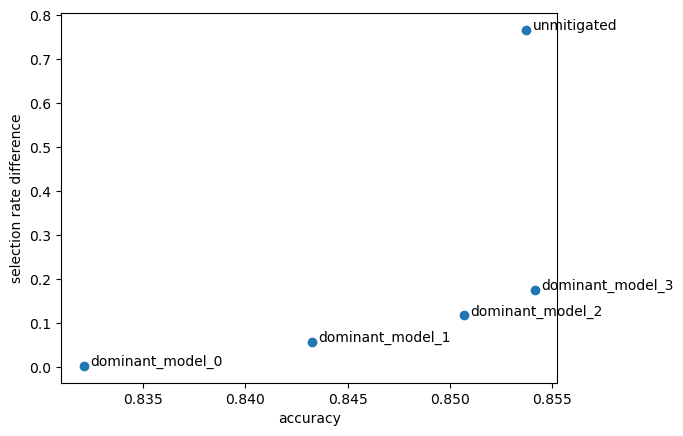

In [15]:
predictions = {"unmitigated": unmitigated_predictor.predict(X_test)}
metric_frames = {"unmitigated": metric_frame}
for i in range(len(non_dominated)):
    key = "dominant_model_{0}".format(i)
    predictions[key] = non_dominated[i].predict(X_test)

    metric_frames[key] = MetricFrame(
        metrics={
            "accuracy": skm.accuracy_score,
            "selection_rate": selection_rate,
            "count": count,
        },
        sensitive_features=A_test,
        y_true=Y_test,
        y_pred=predictions[key],
    )

x = [metric_frame.overall["accuracy"] for metric_frame in metric_frames.values()]
y = [
    metric_frame.difference()["selection_rate"]
    for metric_frame in metric_frames.values()
]
keys = list(metric_frames.keys())
plt.scatter(x, y)
for i in range(len(x)):
    plt.annotate(keys[i], (x[i] + 0.0003, y[i]))
plt.xlabel("accuracy")
plt.ylabel("selection rate difference")

With the code below, you can visualize the quality of the non-dominated models. Just change the id in y_pred=non_dominated[i].predict(X_test) with i in [0, 3]. Pay special attention to the comparison of Male versus Female regarding the selection_rate.

accuracy              0.832119
selection_rate        0.151994
count             12211.000000
dtype: float64
        accuracy  selection_rate   count
sex                                     
Female  0.898868        0.149852  4064.0
Male    0.798822        0.153062  8147.0


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

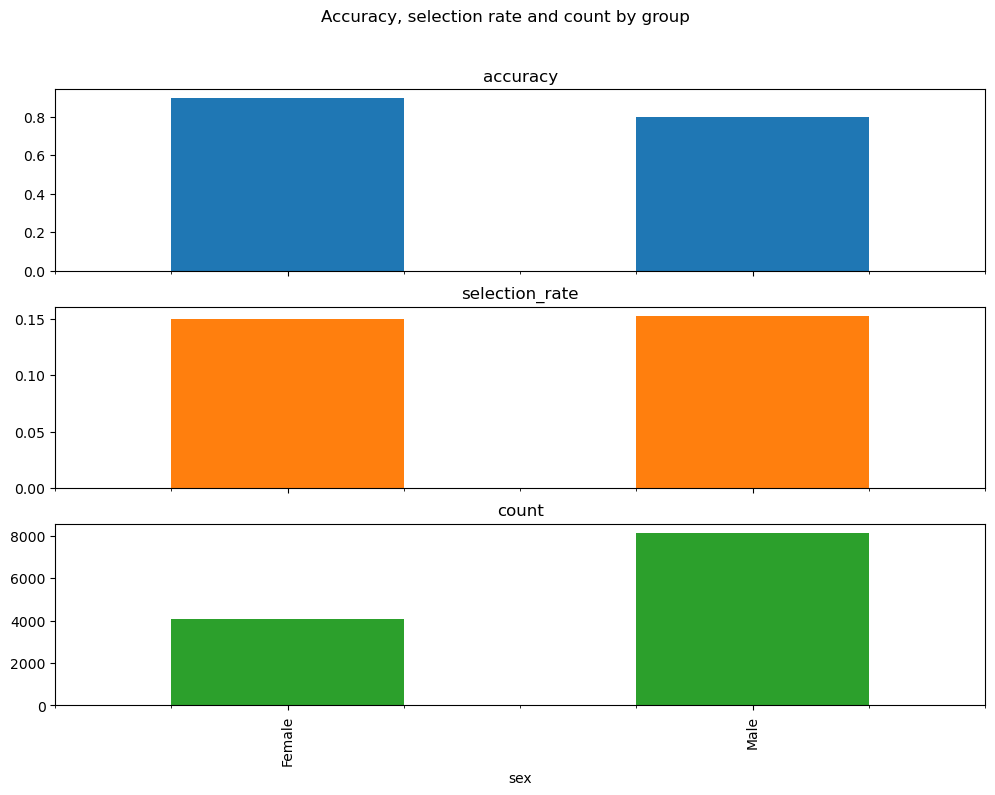

In [16]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=non_dominated[0].predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

### **Exercise 3**
Compare the quality of the models with and without mitigating demographic bias regarding sex. Discuss the observed difference.

accuracy              0.843256
selection_rate        0.164442
count             12211.000000
dtype: float64
        accuracy  selection_rate   count
sex                                     
Female  0.912648        0.125738  4064.0
Male    0.808641        0.183749  8147.0


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

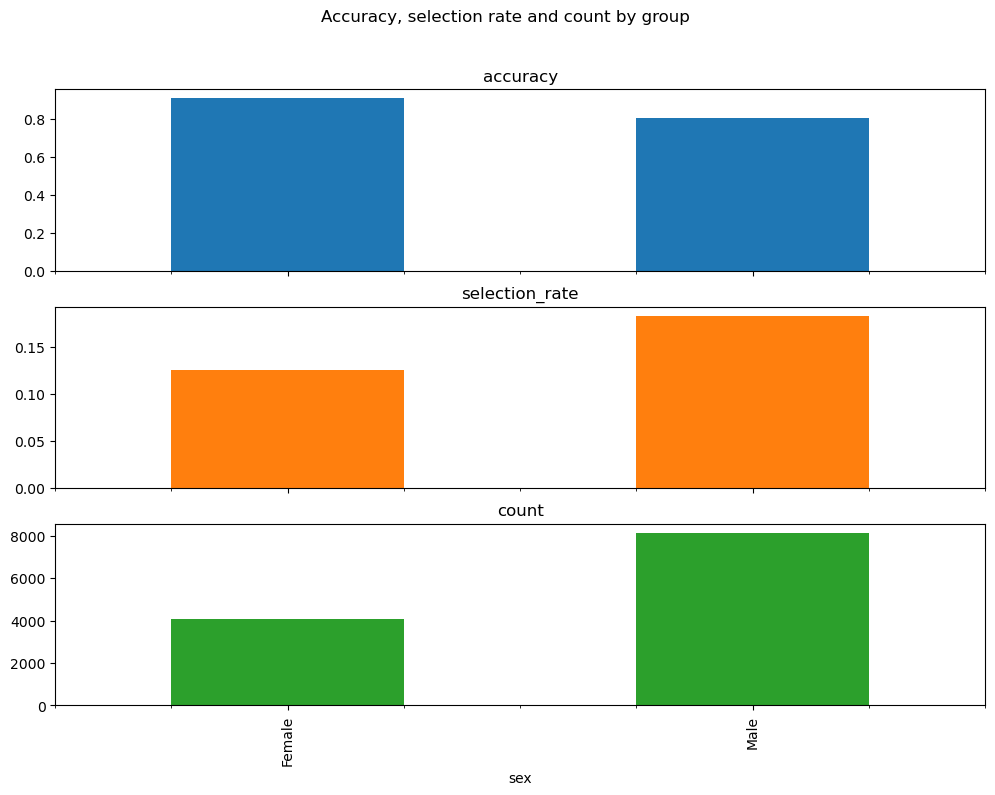

In [17]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=non_dominated[1].predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

accuracy              0.850708
selection_rate        0.178446
count             12211.000000
dtype: float64
        accuracy  selection_rate   count
sex                                     
Female  0.923720        0.099409  4064.0
Male    0.814287        0.217872  8147.0


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

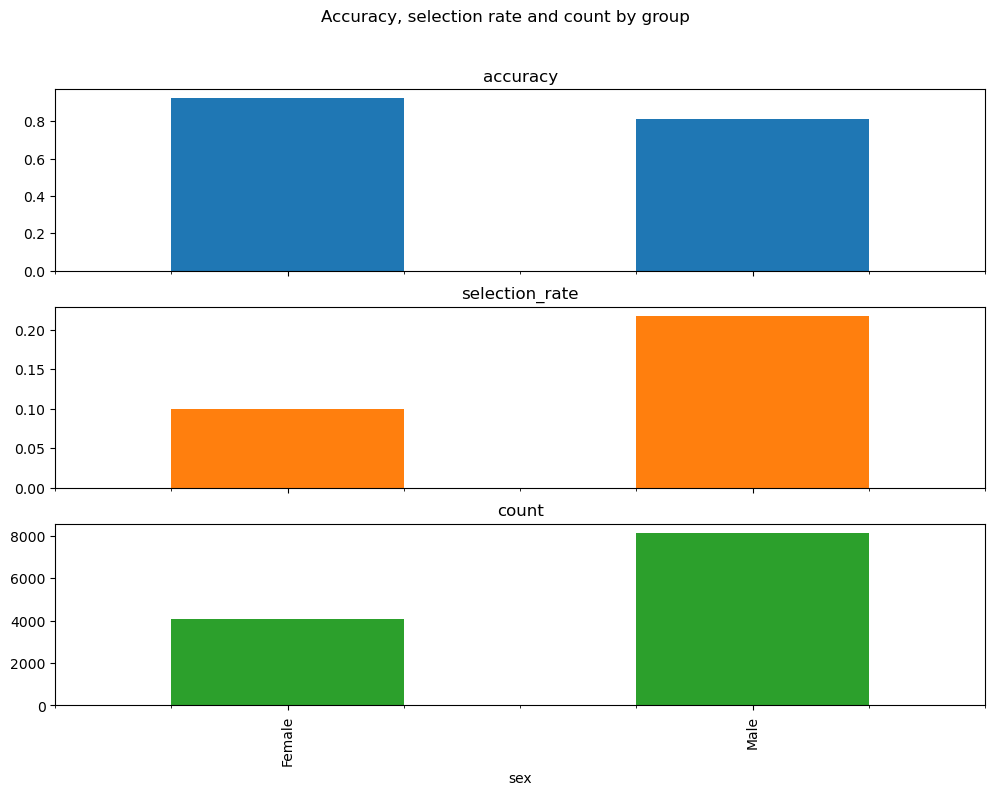

In [18]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=non_dominated[2].predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

accuracy              0.854148
selection_rate        0.194988
count             12211.000000
dtype: float64
        accuracy  selection_rate   count
sex                                     
Female  0.928150        0.077264  4064.0
Male    0.817233        0.253713  8147.0


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

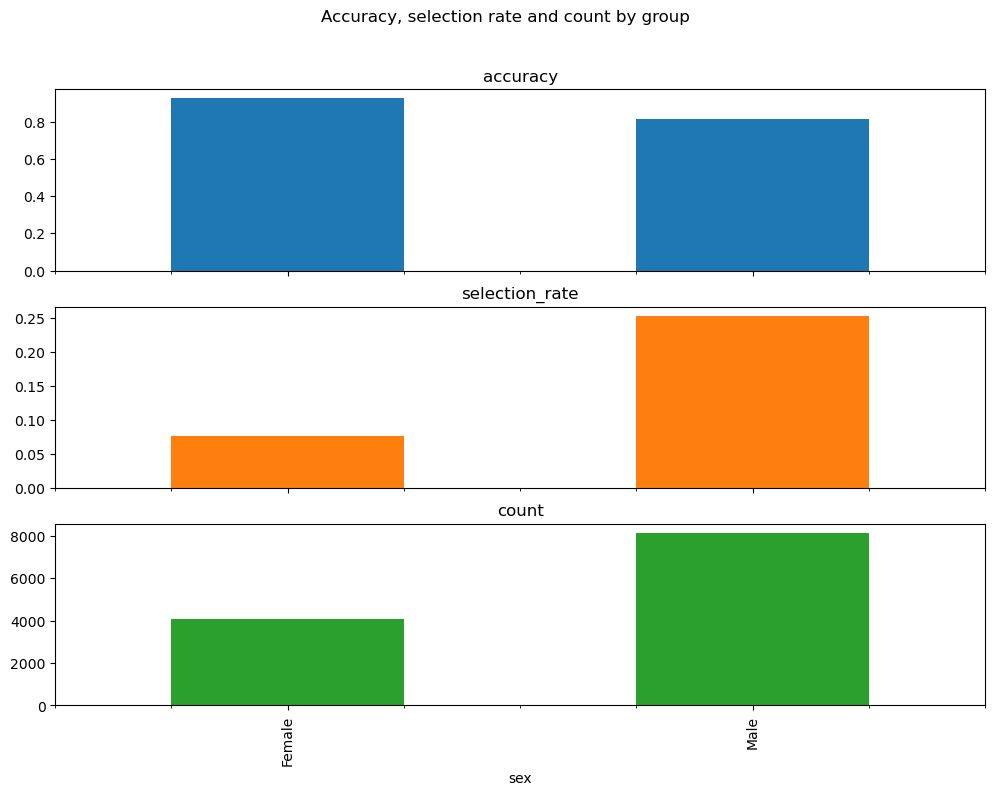

In [19]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=non_dominated[3].predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

### Answer Exercise 3

**Compare the quality of the models with and without mitigating demographic bias regarding sex. Discuss the observed difference.**

`Looking at the results, the unmitigated model achieves high overall accuracy (0.854) and ROC (0.904), but it exhibits a large disparity in selection rates between sexes (Female 0.077 vs Male 0.254), which indicates a strong bias favoring males. The true positive rate also differs substantially (Female 0.525 vs Male 0.617), meaning males are more likely to be correctly classified as positive, while females are more likely to be misclassified.`

`The mitigated models show a clear trend: as the models move along the Pareto front, the selection rate difference between females and males decreases, indicating improved demographic parity. Dominant0, for example, reduces the gap almost completely (Female 0.150 vs Male 0.153) but sacrifices some overall accuracy (0.832). Dominant1 and dominant2 achieve intermediate trade-offs, with slightly higher accuracy (0.843 and 0.851) but also slightly higher selection rate gaps (Female 0.126 vs Male 0.184 for dominant1, Female 0.099 vs Male 0.218 for dominant2). Dominant3 essentially reproduces the unmitigated model (accuracy 0.854, selection rates Female 0.077 vs Male 0.254) and therefore does not improve fairness.`

`Overall, enforcing demographic parity successfully reduces sex-based disparities in selection rates, improving fairness, but this comes at the cost of a modest decrease in overall accuracy, reflecting the typical trade-off between fairness and predictive performance. The unmitigated model is most accurate but highly biased, while the mitigated models allow controlling the bias-accuracy balance.`